In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set seaborn theme
sns.set_theme(style="whitegrid")

pd.set_option('display.max_columns', None)

In [3]:
sns.set_theme(style="whitegrid", palette="deep")

In [5]:
df = pd.read_csv("/content/train.csv.zip")
df.head()

,date,store,item,sales
0,2013-01-01,1,1,13
1,2013-01-02,1,1,11
2,2013-01-03,1,1,14
3,2013-01-04,1,1,13
4,2013-01-05,1,1,10


In [6]:
## Inspecting the dataset
df.shape

(913000, 4)

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 913000 entries, 0 to 912999
Data columns (total 4 columns):
 #   Column  Non-Null Count   Dtype 
---  ------  --------------   ----- 
 0   date    913000 non-null  object
 1   store   913000 non-null  int64 
 2   item    913000 non-null  int64 
 3   sales   913000 non-null  int64 
dtypes: int64(3), object(1)
memory usage: 27.9+ MB


In [9]:
df.describe()

,store,item,sales
count,913000.000000,913000.000000,913000.000000
mean,5.500000,25.500000,52.250287
std,2.872283,14.430878,28.801144
min,1.000000,1.000000,0.000000
25%,3.000000,13.000000,30.000000
50%,5.500000,25.500000,47.000000
75%,8.000000,38.000000,70.000000
max,10.000000,50.000000,231.000000


In [11]:
## Convert date column
df['date'] = pd.to_datetime(df['date'])
df.head()

,date,store,item,sales
0,2013-01-01,1,1,13
1,2013-01-02,1,1,11
2,2013-01-03,1,1,14
3,2013-01-04,1,1,13
4,2013-01-05,1,1,10


In [13]:
## Time features for seasonality and trends
df['year'] = df['date'].dt.year
df['month'] = df['date'].dt.month
df['day'] = df['date'].dt.day
df['week'] = df['date'].dt.isocalendar().week

df.head()

,date,store,item,sales,year,month,day,week
0,2013-01-01,1,1,13,2013,1,1,1
1,2013-01-02,1,1,11,2013,1,2,1
2,2013-01-03,1,1,14,2013,1,3,1
3,2013-01-04,1,1,13,2013,1,4,1
4,2013-01-05,1,1,10,2013,1,5,1


In [14]:
## Missing values
df.isnull().sum()

,0
date,0
store,0
item,0
sales,0
year,0
month,0
day,0
week,0


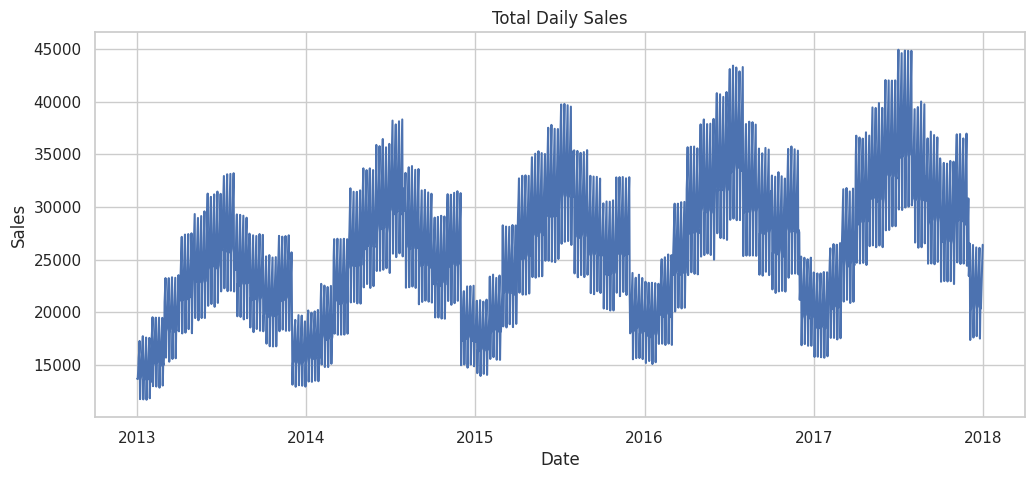

In [15]:
## Sales trend overtime
daily_sales = df.groupby('date')['sales'].sum()

plt.figure(figsize=(12,5))
plt.plot(daily_sales)

plt.title("Total Daily Sales")
plt.xlabel("Date")
plt.ylabel("Sales")

plt.show()

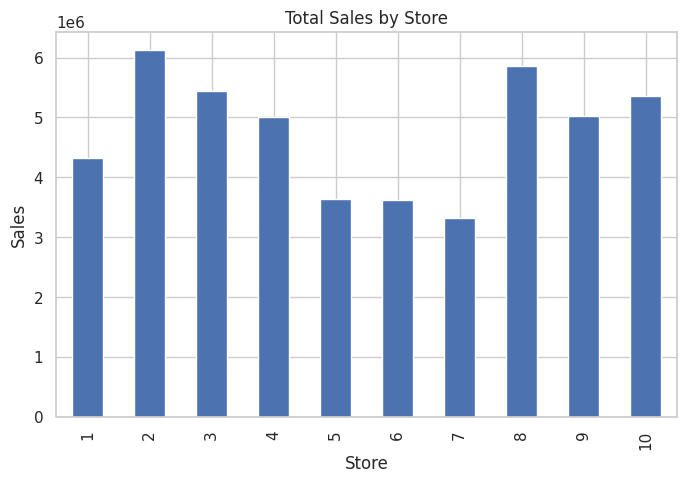

In [16]:
## Sales by store
store_sales = df.groupby('store')['sales'].sum()

plt.figure(figsize=(8,5))
store_sales.plot(kind='bar')

plt.title("Total Sales by Store")
plt.xlabel("Store")
plt.ylabel("Sales")

plt.show()

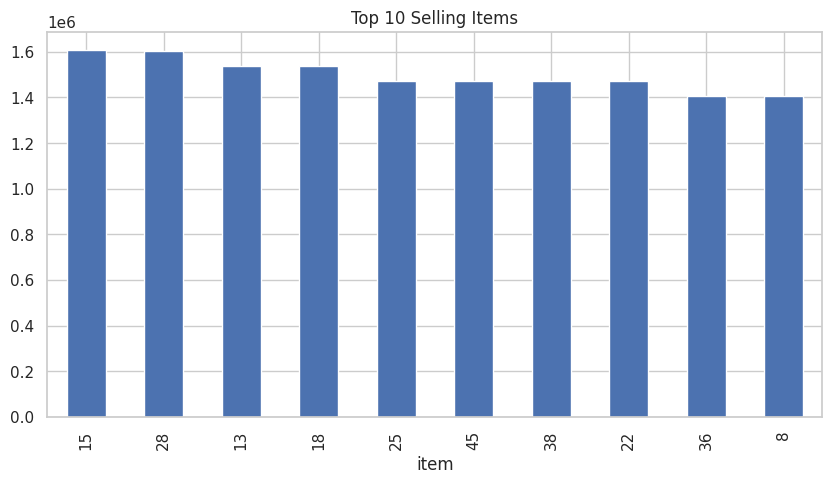

In [17]:
## Top selling items
item_sales = df.groupby('item')['sales'].sum().sort_values(ascending=False)

plt.figure(figsize=(10,5))
item_sales.head(10).plot(kind='bar')

plt.title("Top 10 Selling Items")

plt.show()

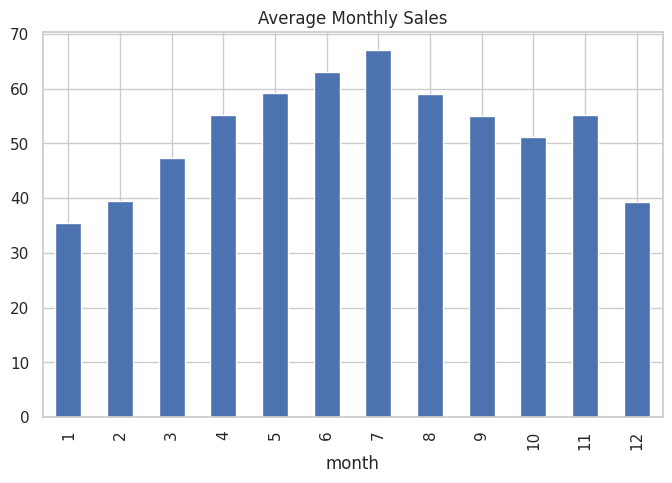

In [18]:
## Monthly seasonality
monthly_sales = df.groupby('month')['sales'].mean()

plt.figure(figsize=(8,5))
monthly_sales.plot(kind='bar')

plt.title("Average Monthly Sales")

plt.show()

In [19]:
## Monthly demand dataset for Demand planners
df['year_month'] = df['date'].dt.to_period('M')

monthly_demand = df.groupby(['year_month','store','item'])['sales'].sum().reset_index()

monthly_demand['year_month'] = monthly_demand['year_month'].dt.to_timestamp()

monthly_demand.head()

,year_month,store,item,sales
0,2013-01-01,1,1,328
1,2013-01-01,1,2,911
2,2013-01-01,1,3,547
3,2013-01-01,1,4,346
4,2013-01-01,1,5,276


In [20]:
## Demand Forecasting
monthly_demand = monthly_demand.sort_values(['store','item','year_month'])

In [21]:
## 3-month moving average forecast
monthly_demand['forecast'] = monthly_demand.groupby(['store','item'])['sales'].transform(lambda x: x.rolling(3).mean())

In [22]:
monthly_demand.head()

,year_month,store,item,sales,forecast
0,2013-01-01,1,1,328,NaN
500,2013-02-01,1,1,322,NaN
1000,2013-03-01,1,1,477,375.666667
1500,2013-04-01,1,1,522,440.333333
2000,2013-05-01,1,1,531,510.000000


In [23]:
## Forecast error and accuracy
monthly_demand['error'] = monthly_demand['sales'] - monthly_demand['forecast']

mae = monthly_demand['error'].abs().mean()

print("Mean Absolute Error:", mae)

Mean Absolute Error: 152.26185057471267


In [24]:
## Average Demand
monthly_demand['avg_demand'] = monthly_demand.groupby(['store','item'])['sales'].transform('mean')

In [26]:
## Demand Variability
monthly_demand['std_demand'] = monthly_demand.groupby(['store','item'])['sales'].transform('std')

In [27]:
## Safety Stock

## Assumptions ##
# 95% service level , Z score = 1.65, Lead time = 7 days

lead_time = 7
z = 1.65

monthly_demand['safety_stock'] = z * monthly_demand['std_demand'] * np.sqrt(lead_time)

In [28]:
## Reorder Point = Average Demand × Lead Time + Safety Stock

monthly_demand['reorder_point'] = (monthly_demand['avg_demand'] * lead_time) + monthly_demand['safety_stock']

In [29]:
## Simulating current Inventory
monthly_demand['current_inventory'] = np.random.randint(100,500,len(monthly_demand))

In [30]:
## Stockout Risk
monthly_demand['stockout_risk'] = np.where(
    monthly_demand['current_inventory'] < monthly_demand['reorder_point'],
    "High Risk",
    "Safe"
)

In [31]:
monthly_demand['stockout_risk'].value_counts()

,count
stockout_risk,
High Risk,30000


In [33]:
## Inventory Turnover

total_sales = df['sales'].sum()

avg_inventory = monthly_demand['current_inventory'].mean()

inventory_turnover = total_sales / avg_inventory

print("Inventory Turnover:", inventory_turnover)

Inventory Turnover: 159072.1822628062


In [35]:
## Exporting Dataset for Visualizations in Power BI
monthly_demand.to_csv("inventory_forecasting_dataset.csv", index=False)

from google.colab import files
files.download("inventory_forecasting_dataset.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>